# Conditioned-MIDI bGPT (Self-Attention Translator) — model validation

Loads the `CondMidiPatchy` dataset and the `MidiBgptTransSelfAttn` / `MidiBgptTransSelfAttnLoss`
model. Unlike `MidiBgptTrans` (cross-attention decoder), this variant folds the conditioning into
a **prefix-LM**: the frozen `lyl_encoder` (a `PatchLevelDecoder`) produces per-patch memory, which
is projected (`enc_proj`) and **scattered into the lilylet-prefix positions** of a joint input
sequence; the midi positions carry the midi patch embedding. A **single HF `LlamaModel`** then runs
self-attention over `[projected-lyl-prefix ; midi]` under the same joint `[B,1,T,T]` windowed mask,
inheriting fused SDPA (no dense `[B,h,T,T]` score matrix) and RoPE positions.

Not numerically equivalent to `MidiBgptTrans` (cross-attention removed); only the encoder weights
transfer, the decoder trains from scratch.

This notebook: inspects a batch, builds the model, verifies the prefix-scatter and that the joint
mask gates the HF backbone, runs a forward pass, checks the freeze / pretrained-load options, then
overfits one batch.

Config: `configs/midi-measurewise-trans-selfattn.yaml` · Data: `~/data/lilylet/midi-measurewise/test20260629/cond-midi.lmmw.pt`

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel

DATA_DIR = str(Path.home() / 'data')
CONFIG = str(REPO_ROOT / 'configs' / 'midi-measurewise-trans-selfattn.yaml')
print('repo:', REPO_ROOT)
print('data dir:', DATA_DIR)

repo: /home/camus/work/deep-starry
data dir: /home/camus/data


## 1. Load dataset + a small CPU model, inspect one batch

The corpus is NOT cropped (`patch_length: 0`), so we shrink the model (not the data) to keep
this validation quick on CPU. A 2-sample batch of differing length exercises padding.

In [2]:
config = Configuration.createOrLoad(CONFIG, volatile=True)
config['data.batch_size'] = 2
config['trainer.device'] = 'cpu'
# smaller model keeps this validation quick on CPU (data stays uncropped)
config['model.args.lyl_hidden_size'] = 64
config['model.args.lyl_patch_num_layers'] = 2
config['model.args.lyl_n_head'] = 4
config['model.args.lyl_num_key_value_heads'] = 4
config['model.args.lyl_intermediate_size'] = 128
config['model.args.d_model'] = 96
config['model.args.n_dec_layer'] = 2
config['model.args.token_num_layers'] = 2
config['model.args.n_head'] = 4
config['model.args.dec_num_key_value_heads'] = 4
config['model.args.num_key_value_heads'] = 4
config['model.args.d_inner'] = 192

train, val = loadDataset(config, data_dir=DATA_DIR, device='cpu')
print('train items:', len(train.dataset), 'val items:', len(val.dataset))

batch = next(iter(train))
print('batch keys:', list(batch.keys()))
for k in ['input_patches', 'input_masks', 'input_targets', 'input_positions', 'attn_mask', 'modality', 'lyl_counts']:
    print(f'  {k:16} {tuple(batch[k].shape)} {batch[k].dtype}')
print('real patches per item :', batch['input_masks'].sum(dim=1).tolist())
print('midi targets per item :', batch['input_targets'].sum(dim=1).tolist())
print('lyl_counts            :', batch['lyl_counts'].tolist())
print('targets only on midi  :', bool(((batch['input_targets'] == 1) & (batch['modality'] == 0)).sum() == 0))

train items: 205 val items: 10


batch keys: ['input_patches', 'input_masks', 'input_targets', 'input_positions', 'attn_mask', 'modality', 'lyl_counts']
  input_patches    (2, 3546, 16) torch.int64
  input_masks      (2, 3546) torch.int64
  input_targets    (2, 3546) torch.int64
  input_positions  (2, 3546) torch.int64
  attn_mask        (2, 1, 3546, 3546) torch.bool
  modality         (2, 3546) torch.int64
  lyl_counts       (2,) torch.int64
real patches per item : [2505, 3546]
midi targets per item : [2160, 3024]
lyl_counts            : [344, 521]
targets only on midi  : True


## 2. Build the model via the factory

In [3]:
deducer = loadModel(config['model'], imports=config['imports'])
model = loadModel(config['model'], postfix='Loss', imports=config['imports'])
print('deducer:', type(deducer).__name__, '| loss model:', type(model).__name__)

d = model.deducer
n_params = sum(p.numel() for p in d.parameters())
n_enc = sum(p.numel() for p in d.lyl_encoder.parameters())
print('MidiBgptTransSelfAttn params: %.2fM (lyl_encoder %.2fM)' % (n_params / 2**20, n_enc / 2**20))
print('lyl_encoder: a', type(d.lyl_encoder).__name__, '(loadable from LilyletNotaGen.patch_level_decoder)')
print('joint decoder:', type(d.decoder).__name__, '| self-attn layers:', d.decoder.config.num_hidden_layers)
print('token-level layers:', d.token_level_decoder.base.config.num_hidden_layers)
print('enc_proj (lyl_hidden -> d_model):', tuple(d.enc_proj.weight.shape))
print('lyl/midi vocab:', d.lyl_vocab_size, '/', d.midi_vocab_size)

deducer: MidiBgptTransSelfAttn | loss model: MidiBgptTransSelfAttnLoss
MidiBgptTransSelfAttn params: 0.75M (lyl_encoder 0.33M)
lyl_encoder: a PatchLevelDecoder (loadable from LilyletNotaGen.patch_level_decoder)
joint decoder: LlamaModel | self-attn layers: 2
token-level layers: 2
enc_proj (lyl_hidden -> d_model): (96, 64)
lyl/midi vocab: 256 / 41


## 3. Prefix-scatter + the joint mask gates the HF backbone

Two structural checks specific to this variant (there is no `_dec_masks`; the joint `[B,1,T,T]`
mask goes straight to the HF Llama backbone as `attention_mask`):

**(a) prefix-scatter** — the projected encoder memory fills exactly the lilylet-prefix positions
`[0, lyl_count)` of the joint embedding, and midi positions carry the midi embedding.

**(b) mask gating** — blocking a real midi query row in the joint mask changes that row's decoder
hidden state, while an unaffected row is bit-identical. This proves the windowed coupling is
actually enforced by the fused-attention backbone (not silently ignored).

In [4]:
m = model.deducer
m.eval()
patches = batch['input_patches'].reshape(len(batch['input_patches']), -1, m.patch_size)
B, T, _ = patches.shape
Lmax = int(batch['lyl_counts'].max())

# reproduce the encoder->project->scatter the forward does, and confirm placement
lyl_patches = patches[:, :Lmax]
lyl_real = ((batch['modality'][:, :Lmax] == 0) & (batch['input_masks'][:, :Lmax] == 1)).long()
lyl_pos = batch['input_positions'][:, :Lmax]
with torch.no_grad():
    memory = m.enc_proj(m.lyl_encoder(lyl_patches, lyl_real, position_ids=lyl_pos)['last_hidden_state'])
    midi_emb = m._midi_embed(patches)
    joint = midi_emb.clone()
    is_lyl = (batch['modality'][:, :Lmax] == 0).unsqueeze(-1)
    joint[:, :Lmax] = torch.where(is_lyl, memory.to(joint.dtype), joint[:, :Lmax])

b = 0
Lb = int(batch['lyl_counts'][b])
scatter_ok = torch.allclose(joint[b, :Lb], memory[b, :Lb].to(joint.dtype), atol=1e-5)
midi_ok = torch.allclose(joint[b, Lb:T], midi_emb[b, Lb:T], atol=1e-5)
print('(a) prefix positions [0,lyl_count) hold projected encoder memory :', bool(scatter_ok))
print('(a) midi positions [lyl_count,T) hold the midi embedding         :', bool(midi_ok))

# (b) mask gating: pick the last real midi query, blank its keys except self, compare hidden states
real_midi = ((batch['modality'][b] == 1) & (batch['input_masks'][b] == 1)).nonzero().flatten()
qrow = int(real_midi[-1])
full = batch['attn_mask'].clone()
blocked = full.clone()
blocked[b, 0, qrow, :] = False
blocked[b, 0, qrow, qrow] = True
with torch.no_grad():
    h_full = m.decoder(inputs_embeds=joint, attention_mask=full, position_ids=batch['input_positions'])['last_hidden_state']
    h_blk = m.decoder(inputs_embeds=joint, attention_mask=blocked, position_ids=batch['input_positions'])['last_hidden_state']
row0 = int(real_midi[0])
print('(b) blocked query row hidden changes  :', not torch.allclose(h_full[b, qrow], h_blk[b, qrow], atol=1e-6))
print('(b) earlier row (unaffected) identical:', torch.allclose(h_full[b, row0], h_blk[b, row0], atol=1e-6))
assert scatter_ok and midi_ok

(a) prefix positions [0,lyl_count) hold projected encoder memory : True
(a) midi positions [lyl_count,T) hold the midi embedding         : True


(b) blocked query row hidden changes  : True
(b) earlier row (unaffected) identical: True


## 4. Forward pass: loss, metrics, inspectRun

In [5]:
model.train()
loss, metric = model(batch)
print('loss:', loss.item())
print('metric:', metric)
assert loss.requires_grad and loss.dim() == 0 and torch.isfinite(loss)

model.eval()
with torch.no_grad():
    insp = model.inspectRun(batch)
print('inspect:', {k: (v if not torch.is_tensor(v) else tuple(v.shape)) for k, v in insp.items()})
assert insp['n_patches'] == sum(batch['input_targets'].sum(dim=1).tolist())

loss: 3.717442512512207
metric: {'acc': 0.013461282476782799, 'err': 0.9865387175232172}


inspect: {'loss': 3.717460870742798, 'acc': 0.013416855596005917, 'err': 0.9865831444039941, 'time_err': 0.9960304857231677, 'logits': (5184, 17, 41), 'target_patches': (5184, 16), 'n_patches': 5184}


## 5. Overfit one batch — loss should drop, acc should rise

In [6]:
model.train()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
history = []
for step in range(20):
    opt.zero_grad()
    loss, metric = model(batch)
    loss.backward()
    opt.step()
    history.append((loss.item(), metric['acc']))
    if step % 5 == 0 or step == 19:
        print(f'step {step:02d}  loss={loss.item():.4f}  acc={metric["acc"]:.4f}')

print('\nloss start -> end:', round(history[0][0], 4), '->', round(history[-1][0], 4))
print('acc  start -> end:', round(history[0][1], 4), '->', round(history[-1][1], 4))
assert history[-1][0] < history[0][0], 'loss did not decrease' 

step 00  loss=3.7174  acc=0.0135


step 05  loss=2.4849  acc=0.5959


step 10  loss=2.0205  acc=0.6228


step 15  loss=1.6476  acc=0.7510


step 19  loss=1.4236  acc=0.7217

loss start -> end: 3.7174 -> 1.4236
acc  start -> end: 0.0135 -> 0.7217


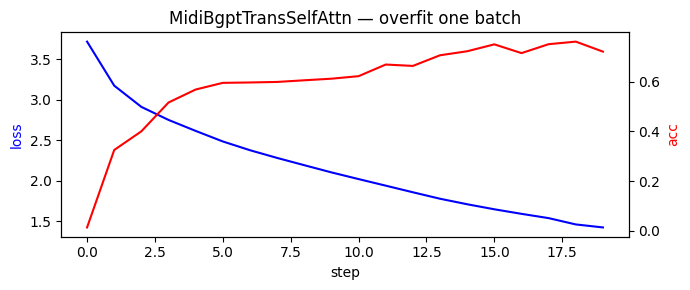

In [7]:
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt

losses = [h[0] for h in history]
accs = [h[1] for h in history]
fig, ax1 = plt.subplots(figsize=(7, 3))
ax1.plot(losses, 'b-', label='loss'); ax1.set_ylabel('loss', color='b'); ax1.set_xlabel('step')
ax2 = ax1.twinx(); ax2.plot(accs, 'r-', label='acc'); ax2.set_ylabel('acc', color='r')
plt.title('MidiBgptTransSelfAttn — overfit one batch'); plt.tight_layout(); plt.show()

## 6. Independent towers: pretrained load + freeze

The `lyl_encoder` is a `PatchLevelDecoder` with the same arch as `LilyletNotaGen.patch_level_decoder`,
so a pretrained NotaGen's patch tower loads into it with **0 missing / 0 unexpected** keys. With
`freeze_lyl_encoder=True` the encoder is detached from training: `requires_grad=False`, kept in
`eval()` even under `model.train()`, no grads, and excluded from `training_parameters()`.

In [8]:
from starry.lilylet.models.notagen import LilyletNotaGen

# (a) key alignment: a real NotaGen patch tower -> lyl_encoder, same arch as the small model here
nota = LilyletNotaGen(base_type='llama', token_vocab_size=256, patch_size=16, patch_length=1024,
    hidden_size=64, patch_num_layers=2, token_num_layers=2, n_head=4, num_key_value_heads=4, intermediate_size=128)
missing, unexpected = model.deducer.lyl_encoder.load_state_dict(nota.patch_level_decoder.state_dict(), strict=False)
print('pretrained load: missing=%d unexpected=%d' % (len(missing), len(unexpected)))
assert not missing and not unexpected

# (b) freeze: build a frozen variant via the factory and verify it is detached from training
config['model.args.freeze_lyl_encoder'] = True
frozen = loadModel(config['model'], postfix='Loss', imports=config['imports'])
frozen.train()  # frozen encoder must stay in eval
n_total = sum(1 for _ in frozen.parameters())
n_train = len([p for p in frozen.deducer.parameters_trainable() if p.requires_grad])
print('freeze: encoder all requires_grad False:', all(not p.requires_grad for p in frozen.deducer.lyl_encoder.parameters()))
print('freeze: encoder stays eval under train():', not frozen.deducer.lyl_encoder.training)
print('freeze: trainable tensors %d of %d total' % (n_train, n_total))

# parameters_trainable is stable under requires_grad_(False) (distributed param-broadcast safety)
n_before = len(frozen.deducer.parameters_trainable())
frozen.requires_grad_(False)
n_after = len(frozen.deducer.parameters_trainable())
print('freeze: parameters_trainable stable under requires_grad_(False): %s (%d==%d)' % (n_before == n_after, n_before, n_after))
frozen = loadModel(config['model'], postfix='Loss', imports=config['imports']); frozen.train()  # fresh (grads restored)

loss_f, _ = frozen(batch); loss_f.backward()
enc_grads = sum(1 for p in frozen.deducer.lyl_encoder.parameters() if p.grad is not None)
dec_grads = sum(1 for p in frozen.deducer.decoder.parameters() if p.grad is not None)
print('freeze: lyl_encoder grad tensors=%d (expect 0), decoder grad tensors=%d (expect >0)' % (enc_grads, dec_grads))
assert enc_grads == 0 and dec_grads > 0
config['model.args.freeze_lyl_encoder'] = False  # restore

pretrained load: missing=0 unexpected=0
freeze: encoder all requires_grad False: True
freeze: encoder stays eval under train(): True
freeze: trainable tensors 45 of 67 total
freeze: parameters_trainable stable under requires_grad_(False): True (45==45)


freeze: lyl_encoder grad tensors=0 (expect 0), decoder grad tensors=19 (expect >0)
